# Street-View Greenery CV Audit

Extract green-view and edge-density indicators from bundled street-view-like images.

This OpenGeoLab case is self-contained: all inputs live in `data/`, and outputs are written to `outputs/`.

Inspired by urban visual intelligence and street-view greenery analysis notebooks; images are locally generated teaching samples.

In [1]:
import os
os.environ.setdefault("PROJ_DATA", "/opt/conda/share/proj")
os.environ.setdefault("PROJ_LIB", "/opt/conda/share/proj")
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import color, filters, feature
from IPython.display import display

DATA = Path('data')
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)
index = pd.read_csv(DATA / 'image_index.csv')
print({'images': len(index)})
display(index.head())


{'images': 12}


,image,district,audit_score
0,street_00.png,D0,93.16
1,street_01.png,D1,59.16
2,street_02.png,D2,63.88
3,street_03.png,D3,49.66
4,street_04.png,D0,54.80


In [2]:
features = []
for row in index.itertuples():
    img_path = DATA / 'images' / row.image
    bgr = cv2.imread(str(img_path))
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    gray = color.rgb2gray(rgb)
    edges = feature.canny(gray, sigma=1.4)
    green_mask = (hsv[:, :, 0] > 35) & (hsv[:, :, 0] < 90) & (hsv[:, :, 1] > 45)
    features.append({
        'image': row.image,
        'district': row.district,
        'audit_score': row.audit_score,
        'green_view_index': float(green_mask.mean()),
        'edge_density': float(edges.mean()),
        'brightness': float(gray.mean()),
    })
features = pd.DataFrame(features)
display(features.sort_values('green_view_index', ascending=False).head())


,image,district,audit_score,green_view_index,edge_density,brightness
1,street_01.png,D1,59.16,0.090413,0.042236,0.393855
2,street_02.png,D2,63.88,0.070394,0.039714,0.359983
0,street_00.png,D0,93.16,0.058350,0.019368,0.405460
10,street_10.png,D2,49.03,0.057780,0.029785,0.384441
9,street_09.png,D1,64.98,0.055420,0.033936,0.389973


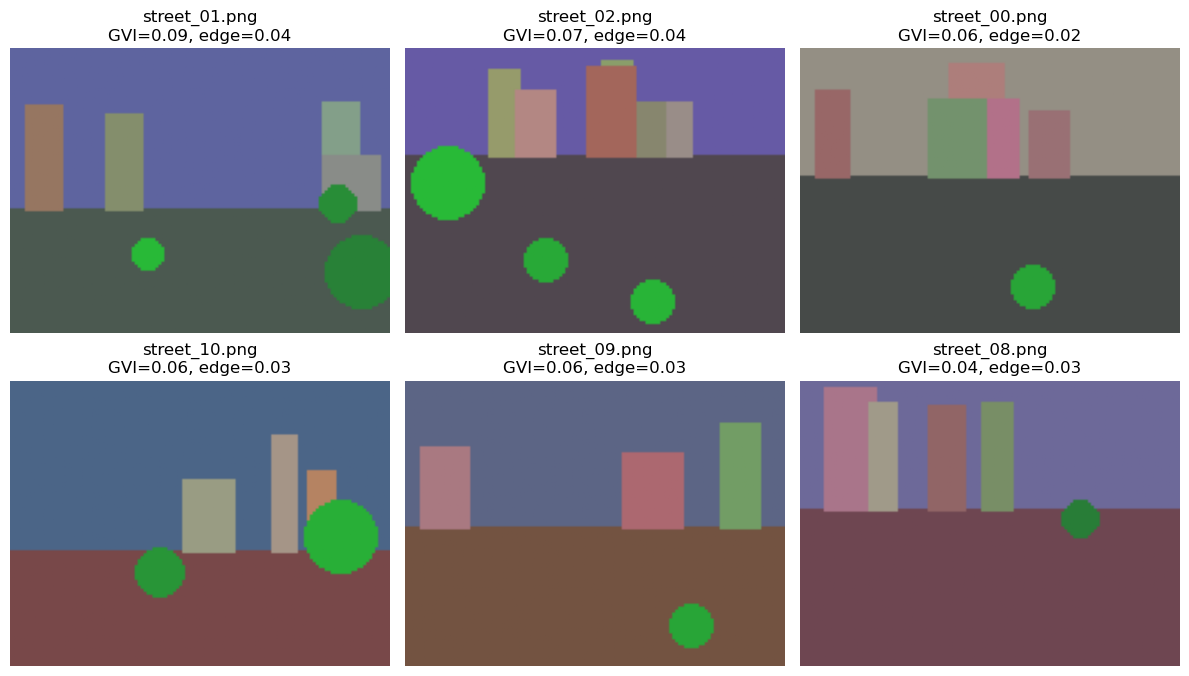

In [3]:
sample = features.sort_values('green_view_index', ascending=False).head(6)
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, row in zip(axes.ravel(), sample.itertuples()):
    img = plt.imread(DATA / 'images' / row.image)
    ax.imshow(img)
    ax.set_title(f'{row.image}\nGVI={row.green_view_index:.2f}, edge={row.edge_density:.2f}')
    ax.set_axis_off()
fig.tight_layout()
fig.savefig(OUT / 'streetview_feature_grid.png', dpi=160)
plt.show()


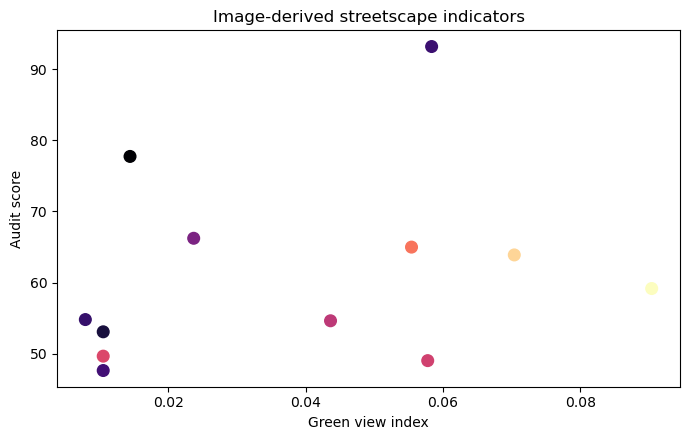

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(features['green_view_index'], features['audit_score'], s=70, c=features['edge_density'], cmap='magma')
ax.set_xlabel('Green view index')
ax.set_ylabel('Audit score')
ax.set_title('Image-derived streetscape indicators')
fig.tight_layout()
fig.savefig(OUT / 'streetscape_indicator_scatter.png', dpi=160)
plt.show()
